In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
import joblib


In [ ]:

df = sns.load_dataset("titanic")

df.to_csv("titanic.csv", index=False)

print("Dataset Information:")
print(df.info())

print("\nDataset Description:")
print(df.describe())

print("\nDataset Shape:")
print(df.shape)

missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent[missing_percent > 0]

print("\nPercentage of Missing Values:")
print(missing_percent)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB
None

Dataset Description:
         survived      pclass         age    

In [19]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [ ]:

df = df.dropna(subset=["embarked", "embark_town"])


df["age"] = df["age"].fillna(df["age"].median())


df = df.drop(columns=["deck"])

print(df.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


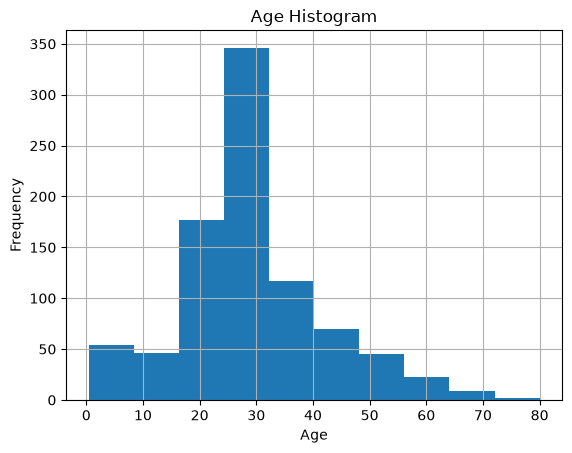

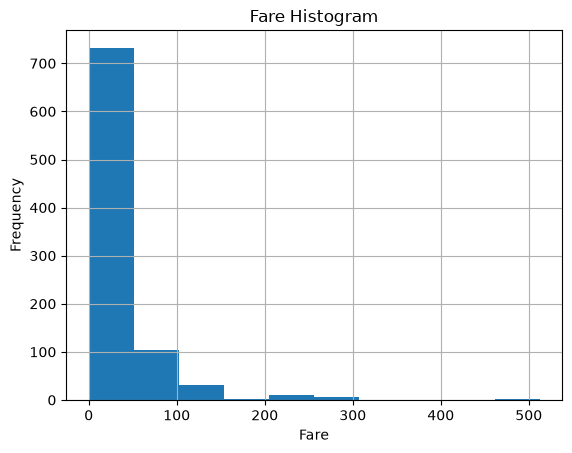

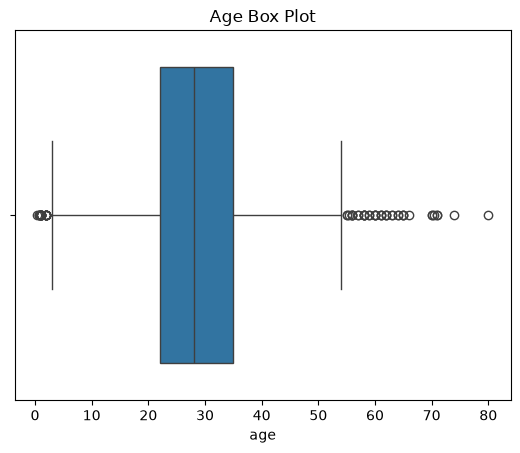

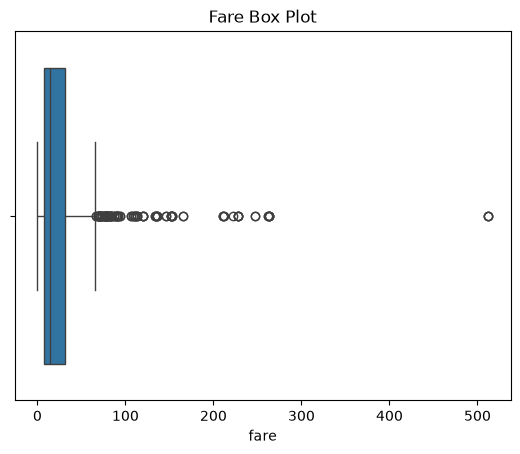

Age outliers: 65
Fare outliers: 114
Fare mean: 32.09668087739032
Fare median: 14.4542
Fare mode: 8.05


In [ ]:

df["age"].hist()
plt.title("Age Histogram")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

df["fare"].hist()
plt.title("Fare Histogram")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()


sns.boxplot(x=df["age"])
plt.title("Age Box Plot")
plt.show()

sns.boxplot(x=df["fare"])
plt.title("Fare Box Plot")
plt.show()


Q1_age = df["age"].quantile(0.25)
Q3_age = df["age"].quantile(0.75)
IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

age_outliers = df[(df["age"] < lower_age) | (df["age"] > upper_age)]

print("Age outliers:", len(age_outliers))


Q1_fare = df["fare"].quantile(0.25)
Q3_fare = df["fare"].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare

lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare

fare_outliers = df[(df["fare"] < lower_fare) | (df["fare"] > upper_fare)]

print("Fare outliers:", len(fare_outliers))

mean_fare = df["fare"].mean()
median_fare = df["fare"].median()
mode_fare = df["fare"].mode()[0]

print("Fare mean:", mean_fare)
print("Fare median:", median_fare)
print("Fare mode:", mode_fare)

The fare distribution is right-skewed because the mean is greater than the median, and the median is greater than the mode (Mean > Median > Mode). This indicates that a relatively small number of passengers paid very high fares, creating a long right tail. The IQR rule was used to identify the outliers in both age and fare.

Male survival rate: 0.18890814558058924
Female survival rate: 0.7403846153846154
Class 1 survival rate: 0.6261682242990654
Class 2 survival rate: 0.47282608695652173
Class 3 survival rate: 0.24236252545824846

Male:
Class 1: 0.36885245901639346
Class 2: 0.1574074074074074
Class 3: 0.13544668587896252

Female:
Class 1: 0.967391304347826
Class 2: 0.9210526315789473
Class 3: 0.5
Correlation Matrix:
          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


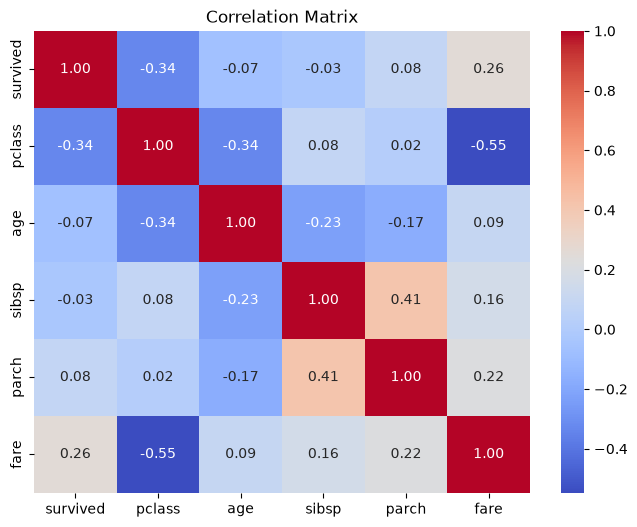


Two strongest correlations:
pclass  fare     0.548193
sibsp   parch    0.414542
dtype: float64


In [ ]:

male_mask = (df["sex"] == "male") | (df["sex"] == "male")
female_mask = (df["sex"] == "female") | (df["sex"] == "female")

print("Male survival rate:", df[male_mask]["survived"].mean())
print("Female survival rate:", df[female_mask]["survived"].mean())


class1_mask = (df["pclass"] == 1) | (df["pclass"] == 1)
class2_mask = (df["pclass"] == 2) | (df["pclass"] == 2)
class3_mask = (df["pclass"] == 3) | (df["pclass"] == 3)

print("Class 1 survival rate:", df[class1_mask]["survived"].mean())
print("Class 2 survival rate:", df[class2_mask]["survived"].mean())
print("Class 3 survival rate:", df[class3_mask]["survived"].mean())


male_class1 = (df["sex"] == "male") & (df["pclass"] == 1)
male_class2 = (df["sex"] == "male") & (df["pclass"] == 2)
male_class3 = (df["sex"] == "male") & (df["pclass"] == 3)

female_class1 = (df["sex"] == "female") & (df["pclass"] == 1)
female_class2 = (df["sex"] == "female") & (df["pclass"] == 2)
female_class3 = (df["sex"] == "female") & (df["pclass"] == 3)

print("\nMale:")
print("Class 1:", df[male_class1]["survived"].mean())
print("Class 2:", df[male_class2]["survived"].mean())
print("Class 3:", df[male_class3]["survived"].mean())

print("\nFemale:")
print("Class 1:", df[female_class1]["survived"].mean())
print("Class 2:", df[female_class2]["survived"].mean())
print("Class 3:", df[female_class3]["survived"].mean())


cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr = df[cols].corr()

print("Correlation Matrix:")
print(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

strongest = upper.abs().stack().sort_values(ascending=False)

print("\nTwo strongest correlations:")
print(strongest.head(2))

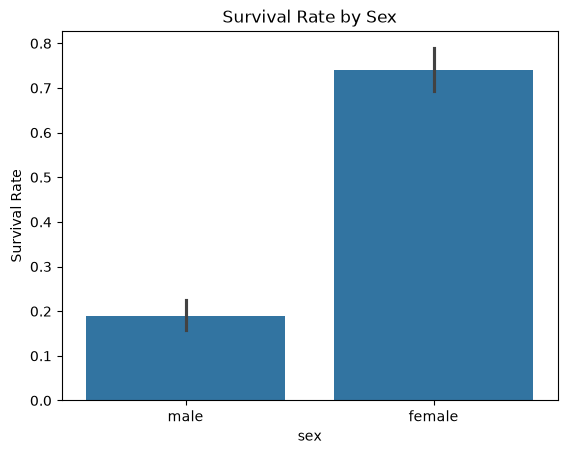

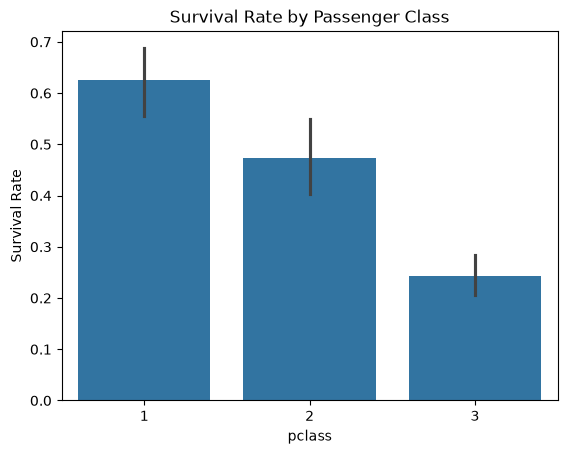

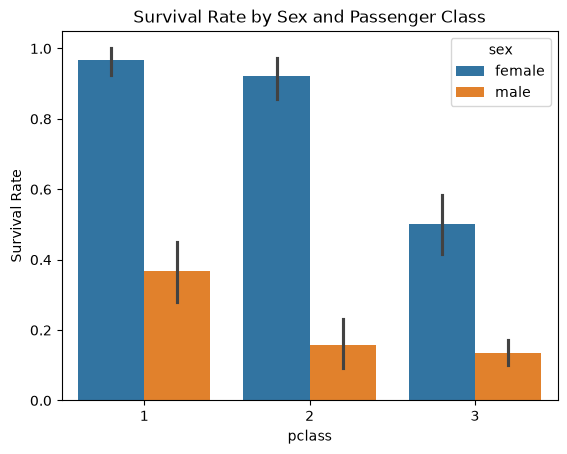

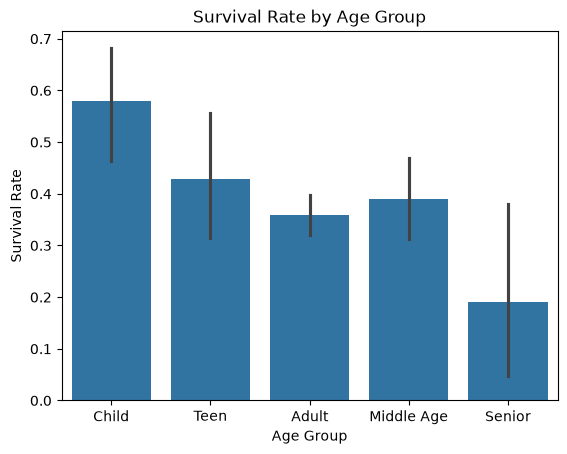

In [ ]:

sns.barplot(data=df, x="sex", y="survived")
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.show()


sns.barplot(data=df, x="pclass", y="survived")
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.show()


sns.barplot(data=df, x="pclass", y="survived", hue="sex")
plt.title("Survival Rate by Sex and Passenger Class")
plt.ylabel("Survival Rate")
plt.show()


df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 12, 18, 40, 60, 100],
    labels=["Child", "Teen", "Adult", "Middle Age", "Senior"]
)

sns.barplot(data=df, x="age_group", y="survived")
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.show()

1. Survival by Sex

The bar plot shows that female passengers had a higher survival rate than male passengers. This indicates a strong association between sex and survival in the Titanic dataset.

2. Survival by Passenger Class

The survival rate differs across passenger classes. First-class passengers had a higher observed survival rate than second- and third-class passengers.

3. Survival by Sex and Passenger Class

The combination of sex and passenger class provides a clearer picture of survival. Female passengers generally had higher survival rates within each class, while survival also varied across passenger classes.

4. Survival by Age Group

Survival rates also varied across age groups. The plot shows how survival differed between children, teenagers, adults, middle-aged passengers, and seniors, providing another dimension to the survival story.

In [ ]:

columns = ["age", "fare"]

print("Before standardization:")
print(df[columns].agg(["mean", "std"]))

scaler = StandardScaler()

df_scaled = df.copy()

df_scaled[columns] = scaler.fit_transform(df[columns])


print("\nAfter standardization:")
print(df_scaled[columns].agg(["mean", "std"]))

Before standardization:
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

After standardization:
               age          fare
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00


In [ ]:

X = df.drop("survived", axis=1)
y = df["survived"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


numeric_features = [
    "age",
    "fare",
    "sibsp",
    "parch",
    "pclass"
]

categorical_features = [
    "sex",
    "embarked"
]


numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])



X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training shape: (711, 10)
Testing shape: (178, 10)


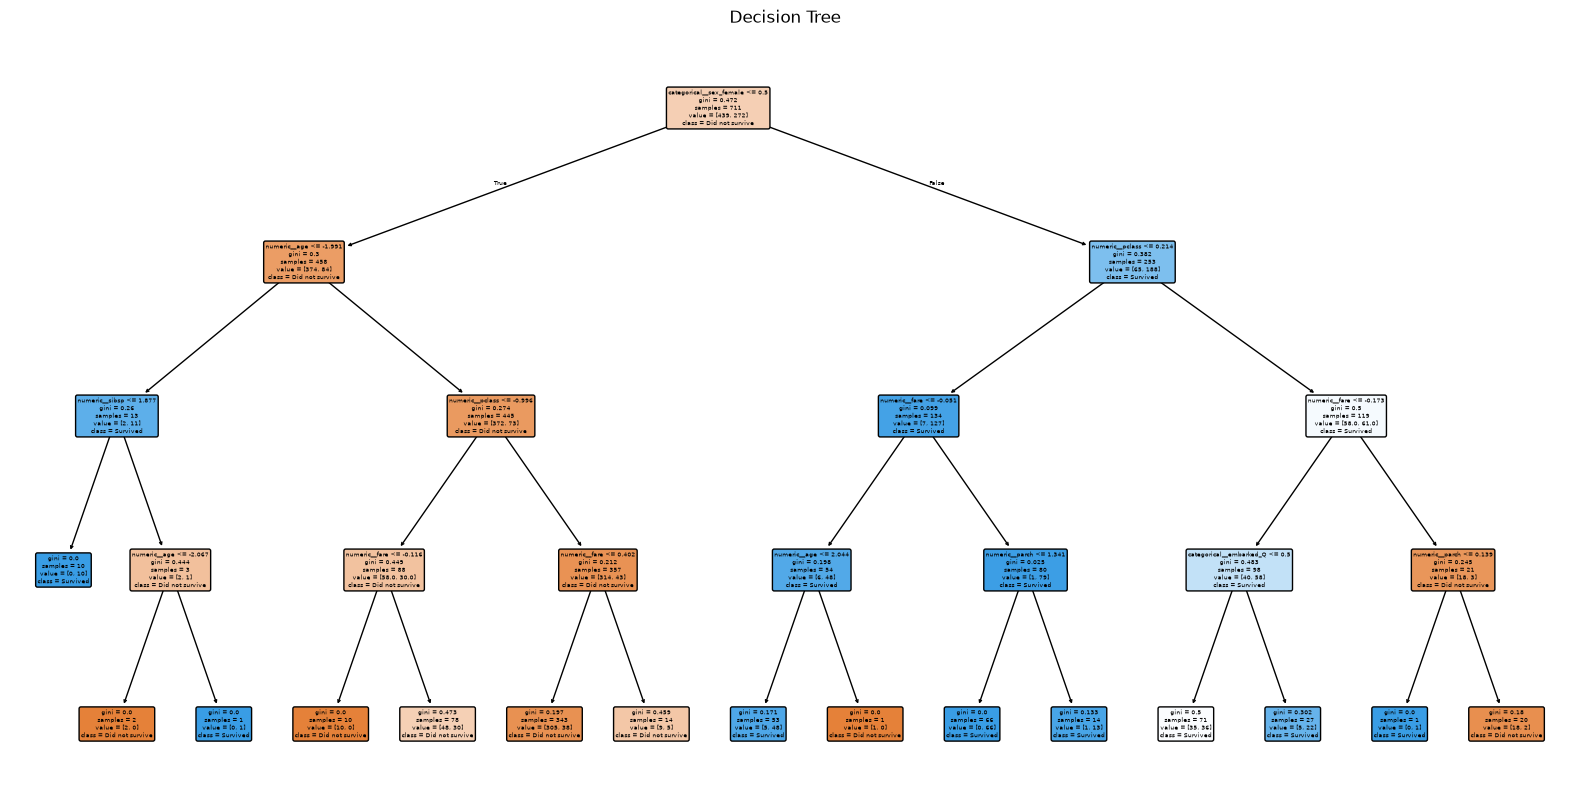

In [ ]:

logistic = LogisticRegression(max_iter=1000)

logistic.fit(X_train_processed, y_train)

logistic_pred = logistic.predict(X_test_processed)



tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=4
)

tree.fit(X_train_processed, y_train)

tree_pred = tree.predict(X_test_processed)



forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest.fit(X_train_processed, y_train)

forest_pred = forest.predict(X_test_processed)


feature_names = preprocessor.get_feature_names_out()

plt.figure(figsize=(20, 10))

plot_tree(
    tree,
    feature_names=feature_names,
    class_names=["Did not survive", "Survived"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree")
plt.show()

Model Comparison
                 Model   TN  FP  FN  TP  Accuracy  Precision  Recall  \
0  Logistic Regression   97  13  21  47     0.809      0.783   0.691   
1        Decision Tree  100  10  24  44     0.809      0.815   0.647   
2        Random Forest   96  14  18  50     0.820      0.781   0.735   

   F1 Score    AUC  
0     0.734  0.861  
1     0.721  0.856  
2     0.758  0.821  


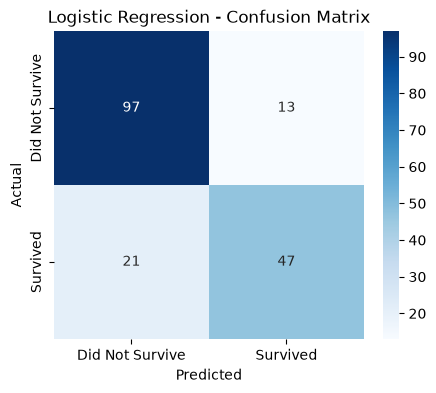

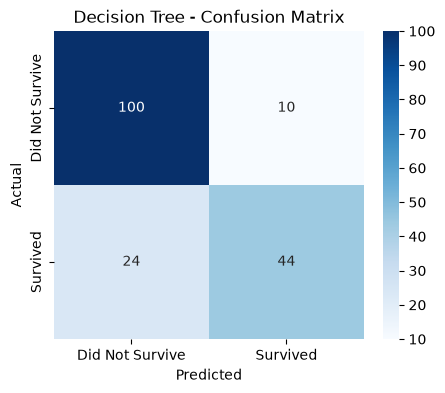

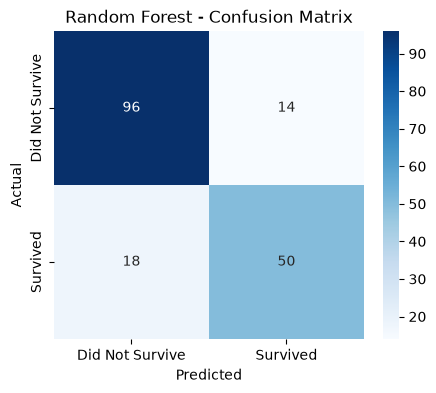

In [ ]:

models = {
    "Logistic Regression": logistic,
    "Decision Tree": tree,
    "Random Forest": forest
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    results.append({
        "Model": name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    })


results_df = pd.DataFrame(results)

print("Model Comparison")
print(results_df.round(3))


for name, model in models.items():

    y_pred = model.predict(X_test_processed)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Did Not Survive", "Survived"],
        yticklabels=["Did Not Survive", "Survived"]
    )

    plt.title(name + " - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [ ]:

print("Class counts:")
print(y.value_counts())

print("\nClass percentages:")
print((y.value_counts(normalize=True) * 100).round(2))


baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train_processed, y_train)

baseline_pred = baseline_model.predict(X_test_processed)

balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

balanced_model.fit(X_train_processed, y_train)

balanced_pred = balanced_model.predict(X_test_processed)

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("\nTraining class counts after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

smote_model = LogisticRegression(max_iter=1000)

smote_model.fit(X_train_smote, y_train_smote)

smote_pred = smote_model.predict(X_test_processed)


results = pd.DataFrame({
    "Method": [
        "Baseline",
        "Class Weight Balanced",
        "SMOTE"
    ],
    "Precision": [
        precision_score(y_test, baseline_pred),
        precision_score(y_test, balanced_pred),
        precision_score(y_test, smote_pred)
    ],
    "Recall": [
        recall_score(y_test, baseline_pred),
        recall_score(y_test, balanced_pred),
        recall_score(y_test, smote_pred)
    ],
    "F1 Score": [
        f1_score(y_test, baseline_pred),
        f1_score(y_test, balanced_pred),
        f1_score(y_test, smote_pred)
    ]
})

print("\nImbalance Handling Comparison:")
print(results.round(3))

Class counts:
survived
0    549
1    340
Name: count, dtype: int64

Class percentages:
survived
0    61.75
1    38.25
Name: proportion, dtype: float64

Training class counts after SMOTE:
survived
1    439
0    439
Name: count, dtype: int64

Imbalance Handling Comparison:
                  Method  Precision  Recall  F1 Score
0               Baseline      0.783   0.691     0.734
1  Class Weight Balanced      0.718   0.750     0.734
2                  SMOTE      0.735   0.735     0.735


In [ ]:

rf = RandomForestClassifier(
    oob_score=True,
    random_state=42
)

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_processed, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_search.best_score_)


best_rf = RandomForestClassifier(
    n_estimators=grid_search.best_params_["n_estimators"],
    max_depth=grid_search.best_params_["max_depth"],
    max_features=grid_search.best_params_["max_features"],
    oob_score=True,
    random_state=42
)

best_rf.fit(X_train_processed, y_train)

print("\nOOB Score:")
print(best_rf.oob_score_)

Best Parameters:
{'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 100}

Best Cross-Validation F1 Score:
0.7420434551195058

OOB Score:
0.8087201125175809


Linear Regression Results
-------------------------
MAE: 0.302
RMSE: 0.38
R²: 0.388
Adjusted R²: 0.352


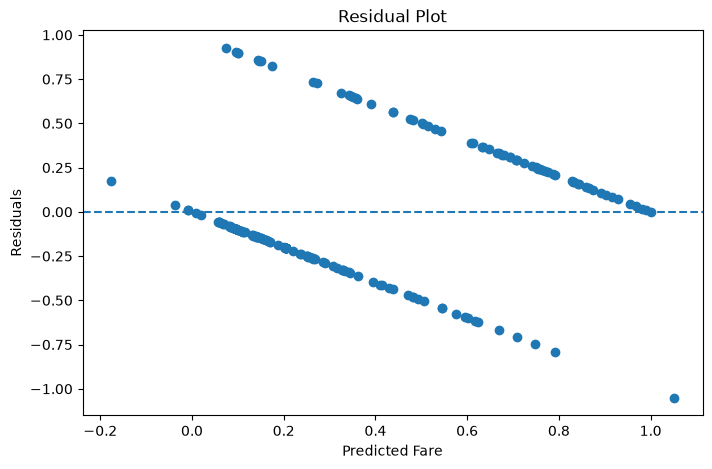

In [ ]:

linear_model = LinearRegression()

linear_model.fit(X_train_processed, y_train)

y_pred = linear_model.predict(X_test_processed)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

n = len(y_test)
p = X_test_processed.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("Linear Regression Results")
print("-------------------------")
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²:", round(r2, 3))
print("Adjusted R²:", round(adjusted_r2, 3))


residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Residual Plot Interpretation: The residual plot shows a clear non-random pattern in the residuals. The residuals form distinct patterns and their spread is not constant across the predicted fare values. Therefore, the plot provides visual evidence of heteroscedasticity, meaning that the variance of the regression errors is not constant.


In [ ]:

classification_results = results_df[
    ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "AUC"]
].copy()

regression_results = pd.DataFrame({
    "Regression Model": ["Linear Regression"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R²": [r2],
    "Adjusted R²": [adjusted_r2]
})


classification_results["MAE"] = np.nan
classification_results["RMSE"] = np.nan
classification_results["R²"] = np.nan
classification_results["Adjusted R²"] = np.nan


regression_row = pd.DataFrame({
    "Model": ["Linear Regression"],
    "Accuracy": [np.nan],
    "Precision": [np.nan],
    "Recall": [np.nan],
    "F1 Score": [np.nan],
    "AUC": [np.nan],
    "MAE": [mae],
    "RMSE": [rmse],
    "R²": [r2],
    "Adjusted R²": [adjusted_r2]
})

model_comparison = pd.concat(
    [classification_results, regression_row],
    ignore_index=True
)

print("MODEL COMPARISON")
print(model_comparison.round(3))

MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1 Score    AUC    MAE  \
0  Logistic Regression     0.809      0.783   0.691     0.734  0.861    NaN   
1        Decision Tree     0.809      0.815   0.647     0.721  0.856    NaN   
2        Random Forest     0.820      0.781   0.735     0.758  0.821    NaN   
3    Linear Regression       NaN        NaN     NaN       NaN    NaN  0.302   

   RMSE     R²  Adjusted R²  
0   NaN    NaN          NaN  
1   NaN    NaN          NaN  
2   NaN    NaN          NaN  
3  0.38  0.388        0.352  


For the classification task, Random Forest is suitable for this dataset because it has the highest accuracy (0.820) and F1 score (0.758). It also has the highest recall (0.735) with good precision (0.781). However, Logistic Regression has a higher AUC score (0.861) compared with Random Forest (0.821), showing better class separation. Overall, I would choose Random Forest because it gives better accuracy, recall, and F1 score.

In [ ]:

full_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])


full_pipeline.fit(X_train, y_train)


joblib.dump(full_pipeline, "titanic_random_forest_pipeline.joblib")

print("Pipeline saved successfully.")

Pipeline saved successfully.


In [ ]:


loaded_pipeline = joblib.load("titanic_random_forest_pipeline.joblib")

predictions = loaded_pipeline.predict(X_test)

print("Predictions:")
print(predictions[:10])

print("Actual values:")
print(y_test.iloc[:10].values)

Predictions:
[0 0 0 0 0 1 0 1 1 0]
Actual values:
[0 0 0 0 0 0 0 1 1 1]
